In [5]:
import os
# 1. 优先设置所有的环境变量（必须在 import torch 之前！）
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"   # 解决 Mac M4 内核崩溃问题
os.environ['CUDA_VISIBLE_DEVICES'] = '0,1'    # 限制服务器上只用 0,1 号卡

import sys
import numpy as np 
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import torch.optim as optim

batch_size = 16
lr = 1e-4
max_epochs = 100

# 2. 智能识别设备（此时服务器上的 cuda:0 实际对应的就是物理上的 0 号卡）
if torch.cuda.is_available():
    device = torch.device("cuda:0") 
elif torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")

print(f"代码自动识别并连接到了: {device}")


代码自动识别并连接到了: mps


In [6]:
from torchvision import datasets
from torchvision.transforms import ToTensor
training_data = datasets.MNIST(
    root="data",
    train=True,
    download=True,
    transform=ToTensor()
)
test_data = datasets.MNIST(
    root="data",
    train=False,
    download=True,
    transform=ToTensor()
)

print("training data size", len(training_data))
print("test data size", len(test_data))

training data size 60000
test data size 10000


In [7]:
image, label = training_data[0]
print(image.shape)
print(image.dtype)
print(image.min())
print(image.max())
print(label)

torch.Size([1, 28, 28])
torch.float32
tensor(0.)
tensor(1.)
5


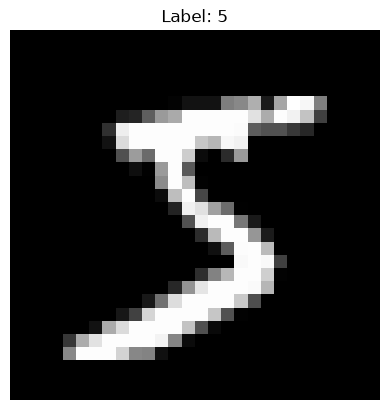

In [8]:
# show image
import matplotlib.pyplot as plt
plt.imshow(image.squeeze(0), cmap="gray")
plt.title(f"Label: {label}")
plt.axis("off")
plt.show()
